# Churn_Project_Notebook


## Abstract

This notebook works on a dataset of a fabrificated telecom company, and will work to calculate a user's churn chances. We plan to use **Xgboost** as our main  model once preperation and EDA is done. The **DiMarino test** may prove to be useful as well

2 main ideas we cover:

Finding what clients churn

Finding how to prevent such clients from churning


## Project Structure
**1. Data Preparation**
- Load raw dataset
- Inspect data structure and variables
- Convert data types (e.g., datetime conversion)
- Assess and handle missing values
- Check for duplicate records
- Validate numerical ranges and categorical consistency
- Remove non-predictive features (e.g., customer ID)
- Export cleaned dataset

**2. Exploratory Data Analysis (EDA)**
- Analyse churn distribution
- Investigate customer demographics and churn relationships
- Analyse customer engagement and satisfaction factors
- Explore service usage patterns
- Analyse financial behaviour and churn relationships
- Identify important trends and patterns

**3. Feature Engineering**
- Create new meaningful customer features
- Extract useful information from dates
- Transform variables for modelling
- Prepare features and target variable

**4. Model Development**
- Split data into training and testing sets
- Encode categorical variables
- Train baseline model (Logistic Regression)
- Train advanced models (Random Forest, XGBoost)
- Compare model performance

**5. Model Evaluation**
- Evaluate models using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC
- Analyse confusion matrix
- Select best performing model

**6. Model Interpretation**
- Identify key churn drivers
- Analyse feature importance
- Explain model predictions
- Translate findings into customer retention insights

**7. Conclusion and Recommendations**
- Summarise model performance
- Discuss important churn factors
- Provide business recommendations to reduce customer churn

## How to Run This Notebook

-Currently just local


## Environment Setup (Colab + Local)

We first upload the raw data to begin working with it.

In [10]:
import pandas as pd
df = pd.read_csv("customer_churn.csv")
df.columns #Display all collumns



Index(['customer_id', 'signup_date', 'age', 'gender', 'annual_income',
       'education', 'marital_status', 'dependents', 'tenure', 'contract',
       'payment_method', 'paperless_billing', 'senior_citizen',
       'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service',
       'has_internet_service', 'has_online_security', 'has_online_backup',
       'has_device_protection', 'has_tech_support', 'has_streaming_tv',
       'has_streaming_movies', 'customer_satisfaction', 'num_complaints',
       'num_service_calls', 'late_payments', 'avg_monthly_gb',
       'days_since_last_interaction', 'credit_score', 'churn'],
      dtype='object')

## Step 1: Convert Date Column

The `Date` column is stored as integer (YYYYMMDD). Convert to proper datetime index.

In [11]:
#Convert date column
df["signup_date"] = pd.to_datetime(df["signup_date"])

# Check data
print(f"Date range: {df['signup_date'].min().date()} to {df['signup_date'].max().date()}")
df.head()

Date range: 2021-01-13 to 2026-01-11


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


## Step 2: Assess Missing Data

Client records may be incomplete so missing values are expected. We need a coverage thershold to remove incosistent data, records with too little information will be removed. 

                       Missing Values  Percentage Missing
avg_monthly_gb                  50012                5.00
credit_score                    40395                4.04
annual_income                   29959                3.00
num_complaints                  29906                2.99
customer_satisfaction           19921                1.99


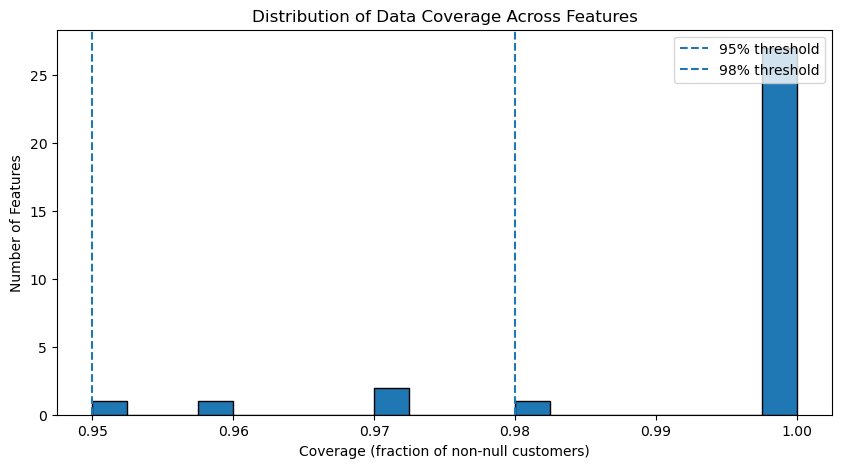

In [12]:
# Check missing values
import matplotlib.pyplot as plt
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage Missing": (df.isnull().mean() * 100).round(2)
})

# Display only columns with missing values
print(missing_data[missing_data["Missing Values"] > 0].sort_values("Missing Values",ascending=False))
coverage = df.notna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of coverage
ax.hist(coverage, bins=20, edgecolor='black')

# Threshold lines
ax.axvline(0.95, linestyle='--', label='95% threshold')
ax.axvline(0.98, linestyle='--', label='98% threshold')

ax.set_xlabel('Coverage (fraction of non-null customers)')
ax.set_ylabel('Number of Features')
ax.set_title('Distribution of Data Coverage Across Features')
ax.legend()

plt.show()

As very little data is missing we will not need to compute a high threshold. We can visually see the amount of missing data via a histogram shown above, with threhsolds of 5% and 2% shown as well

## Step 3 Handle missing Data

As only 2-5% of data is missing, removing rows is not needed. Since the missing proportion was relatively small and removing records would unnecessarily reduce the dataset size, we will replace numerical values using median imputation. The median was selected because it is less sensitive to outliers compared with the mean.

In [13]:
# Handle missing values via median imputation
# avg_monthly_gb is imputed by group (has_internet_service), since usage
# patterns differ substantially depending on internet subscription status
df["avg_monthly_gb"] = df.groupby("has_internet_service")["avg_monthly_gb"].transform(
    lambda x: x.fillna(x.median())
)

# Remaining numerical columns imputed using a simple global median
for col in ["credit_score", "annual_income", "num_complaints", "customer_satisfaction"]:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values after imputation:
customer_id                    0
signup_date                    0
credit_score                   0
days_since_last_interaction    0
avg_monthly_gb                 0
late_payments                  0
num_service_calls              0
num_complaints                 0
customer_satisfaction          0
has_streaming_movies           0
dtype: int64


## Step 4 Data validation

We now check if any values dont make sense before we start analysing, and compute our final readings on the raw data before exporting the clean dataset.

In [14]:
# 4.1 Check duplicate records

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")


# 4.2 Customer ID uniqueness


unique_ids = df["customer_id"].nunique()
total_rows = df.shape[0]

print("\nCustomer ID Check:")
print(f"Unique customer IDs: {unique_ids}")
print(f"Total customers: {total_rows}")

if unique_ids == total_rows:
    print("All customer IDs are unique.")
else:
    print("Duplicate customer IDs found.")


# 4.3 Check age, income, charge, credit score ranges


print("\nSummary:")
display(df.describe().T)


# Age check
print("\nAge Range:")
print(f"Minimum age: {df['age'].min()}")
print(f"Maximum age: {df['age'].max()}")


# Income check
print("\nAnnual Income Range:")
print(f"Minimum income: {df['annual_income'].min()}")
print(f"Maximum income: {df['annual_income'].max()}")


# Charges check
print("\nCharges Range:")
print(df[["monthlycharges", "totalcharges"]].describe())


# Credit score check
print("\nCredit Score Range:")
print(f"Minimum credit score: {df['credit_score'].min()}")
print(f"Maximum credit score: {df['credit_score'].max()}")


# 4.4 Check categorical values

categorical_cols = [
    "gender",
    "education",
    "marital_status",
    "contract",
    "payment_method",
    "paperless_billing"
]

print("\nCategorical Variable Checks:")

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


# 4.5 Check churn distribution

print("\nChurn Distribution:")
print(df["churn"].value_counts())

print("\nChurn Percentage:")
print((df["churn"].value_counts(normalize=True) * 100).round(2))

Duplicate rows: 0
No duplicates found.

Customer ID Check:
Unique customer IDs: 1000000
Total customers: 1000000
All customer IDs are unique.

Summary:


,count,mean,min,25%,50%,75%,max,std
signup_date,1000000,2023-07-14 13:39:07.319759616,2021-01-13 12:53:58.205311,2022-04-14 12:54:00.628653312,2023-07-14 12:54:09.002999040,2024-10-12 12:54:09.319736320,2026-01-11 12:54:09.480291,NaN
age,1000000.0,44.724603,18.0,34.0,44.0,55.0,90.0,14.479468
annual_income,1000000.0,58493.70376,20000.0,33185.465,48954.6,72420.44,250000.0,36615.298358
dependents,1000000.0,0.799831,0.0,0.0,1.0,1.0,5.0,0.893654
tenure,1000000.0,22.381923,1.0,6.0,16.0,33.0,72.0,20.073341
senior_citizen,1000000.0,0.199511,0.0,0.0,0.0,0.0,1.0,0.399633
monthlycharges,1000000.0,86.443701,20.0,70.49,85.48,100.68,854.95673,27.59243
totalcharges,1000000.0,1837.321438,16.3,484.53,1249.75,2617.66,16252.861508,1803.721634
num_services,1000000.0,2.563721,1.0,1.0,2.0,3.0,6.0,1.41233
has_phone_service,1000000.0,0.769551,0.0,1.0,1.0,1.0,1.0,0.42112



Age Range:
Minimum age: 18
Maximum age: 90

Annual Income Range:
Minimum income: 20000.0
Maximum income: 250000.0

Charges Range:
       monthlycharges    totalcharges
count  1000000.000000  1000000.000000
mean        86.443701     1837.321438
std         27.592430     1803.721634
min         20.000000       16.300000
25%         70.490000      484.530000
50%         85.480000     1249.750000
75%        100.680000     2617.660000
max        854.956730    16252.861508

Credit Score Range:
Minimum credit score: 300.0
Maximum credit score: 850.0

Categorical Variable Checks:

--- gender ---
gender
Male      490166
Female    489595
Other      20239
Name: count, dtype: int64

--- education ---
education
bachelor       300324
college        249610
high_school    249348
master         150468
phd             50250
Name: count, dtype: int64

--- marital_status ---
marital_status
married     450115
single      350830
divorced    148976
widowed      50079
Name: count, dtype: int64

--- contract 

### Findings:
-  **No duplicate records** were identified, and **all customer IDs were unique**, indicating each row represents a distinct customer.
- Missing values were successfully handled earlier, with remaining variables containing complete records.
- Numerical variables were within realistic ranges, with no obvious invalid values detected.
- Categorical variables contained consistent labels with no duplicate category representations.
- The target variable (**churn**) is **imbalanced**, with approximately **90.1% of customers retained and 9.9% of customers churning**. Model evaluation should therefore focus on metrics beyond accuracy, such as precision, recall, F1-score, and ROC-AUC.
- We will evaluate the model's ability to identify customers who actually churned by focusing on *recall*. 
- Some variables, such as **monthlycharges**, contain **potential outliers** (mean 85.5 and max 855) that will be further investigated during exploratory data analysis.

## Step 5 Cleaned Data

#We now can export the clean data. 

In [15]:
# Create cleaned dataset copy
df_clean = df.copy()

# Remove customer ID (Not needed for prediction)
df_clean = df_clean.drop(columns=["customer_id"])

# Export cleaned dataset
df_clean.to_csv("customer_churn_cleaned.csv", index=False)

# Check result
print(df_clean.shape)
df_clean.head()

(1000000, 31)


,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,electronic_check,...,1,1,9.0,0.0,0,0,109.63,16,680.0,0
1,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,bank_transfer,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,credit_card,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,bank_transfer,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,credit_card,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


# Section 2

In [16]:
missing_mask = df["avg_monthly_gb"].isna()  # run this on the RAW pre-imputed data if you still have it
df.loc[missing_mask, "has_internet_service"].value_counts()

Series([], Name: count, dtype: int64)

In [17]:
df[df["avg_monthly_gb"] == 27.77]["has_internet_service"].value_counts()

has_internet_service
1    155
Name: count, dtype: int64